In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

Use numpy for representing the hamiltonian to begin with, and possibly use qutip or qiskit later as a higher-level representation.

The entire process of getting to the final Hamiltonian (represented as $c_1 Z + c_2 X$) can roughly be described as:
1. H2 geometry
2. encode basis set (STO-3G)
3. calculate one/two electron integrals
4. construct second-quantized Hamiltonian
5. Jordan-Wigner transformation
6. get 4-qubit Pauli Hamiltonian
7. symmetry reduction / tapering
8. get reduced 1-qubit Hamiltonian
9. final representation

Of course, we could just:

In [2]:
I = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j,  0]], dtype=complex)
Z = np.array([[1,  0], [0, -1]], dtype=complex)

c1 = 0.78796736
c2 = 0.18128881

H = c1 * Z + c2 * X

But that's not fun. Instead, start with the electronic structure:


### $H_2$ Geometry

2 hydrogen nuclei separated by some distance $R$ (in the paper, they use equilibrium geometry with a distance of 0.7414 Å)

In [3]:
R_angstrom = 0.7414
R = R_angstrom * 1.8897259886

Note that we're converting to bohr, because later formulas will naturally use atomic units.

The next step introduces the STO-3G basis (slater-type orbital approximated by three gaussian-type orbitals). Mathematically:
$$
\mathcal{X}_\mu(r)= \sum_{p=1}^3 d_{\mu p}g_{\mu p}(r)
$$

(where $g$ is a gaussian function centered on the nucleus)

Each spatial orbital can have 2 spin states, resulting in a total of 4 spin orbitals (also 4 qubits).

(probably needs a more in depth explanation of STO-3G)

Hydrogen uses only one basis function $1s$

$$
\mathcal{X}_{1s} = c_1 G(\alpha_1) + c_2 G(\alpha_2) + c_3 G(\alpha_3)
$$

$$
G(\alpha, r) = N\mathrm{e}^{-\alpha r^2}
$$

where $N$ is the normalization constant. For an s-type gaussian in 3D:

$$
N = \left( \frac{2\alpha}{\pi}^{3/4} \right)
$$

The following are the actual values of the coefficients and exponents for the $1s$ basis set:

In [4]:
exponents = [3.42525091, 0.62391373, 0.16885540]
coefficients = [0.15432897, 0.53532814, 0.44463454]

N_constant = lambda a: ((2 * a) / math.pi)**0.75

primitive_gaussian = lambda a, r: N_constant(a) * math.exp(-a * r**2)

def sto3g_1s(r):
    value = 0.0

    for a, c in zip(exponents, coefficients):
        value += c * primitive_gaussian(a, r)

    return value

Now we define the two hydrogen centres (our corresponding to two values of R) and evaluate the orbital at different values, by calculating the distance from each nucleus and evaluating the basis function centered on each H. This is also known as LCAO (Linear Combination of Atomic Orbitals).

In [5]:
RA = -R / 2
RB = R / 2

x_values = np.linspace(-3, 3, 500)

psi_values = []

for x in x_values:

    rA = abs(x - RA)
    rB = abs(x - RB)

    phi_A = sto3g_1s(rA)
    phi_B = sto3g_1s(rB)

    psi = phi_A + phi_B

    psi_values.append(psi)

Let's try plotting the molecular orbital now, with `matplotlib`:

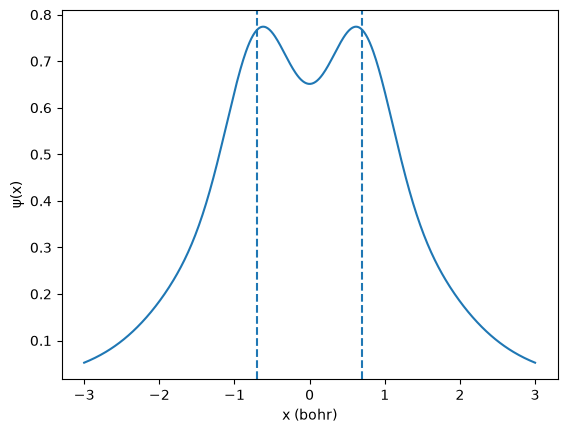

In [6]:
plt.plot(x_values, psi_values)

plt.axvline(RA, linestyle="--")
plt.axvline(RB, linestyle="--")

plt.xlabel("x (bohr)")
plt.ylabel("ψ(x)")
plt.show()

Yay we have a plot now. Time to move on to...

### One- and two-electron integrals

The integrals tells us how the basis functions interact with each other, for example how much they overlap. A one-electron integral has the general form:

$$
\int \phi_A(r)\hat h \phi_B(r) dr
$$

where $\hat h$ is a one-electron operator:

$$
\hat h = -\frac12 \nabla^2 - \frac{1}{r_A} - \frac{1}{r_B}
$$

where the first term is the kinetic energy and the latter two describe the attraction to the nuclei. So the final integral looks like:

$$
h_{\mu v} = \int \phi_\mu \left( -\frac12 \nabla^2 - \frac{1}{r_A} - \frac{1}{r_B} \right) \phi_v dr
$$

As for two-electron integrals, we also have to account for repulsion. For electrons at position 1 and 2, we have the repulsion $\frac{1}{r_{12}}$ where $r_{12} = |r_1 - r_2|$, so the final integral looks like:

$$
(\mu v | \lambda\sigma) = \int\int \phi_\mu(r_1)\phi_v(r_1) \frac{1}{r_{12}} \phi_\lambda(r_2)\phi_\sigma(r_2)dr_1dr_2
$$

Physically represents how strongly the two electron distributions repel each other. For $H_2$ we need two one-electron terms (one for each atom) and one two-electron terms. To implement this, we first create the two basis functions $\phi_A$ and $\phi_B$. We already have the code, we just need to turn it into functions:

In [7]:
def phi_A(x):
    rA = abs(x - RA)
    return sto3g_1s(rA)


def phi_B(x):
    rB = abs(x - RB)
    return sto3g_1s(rB)

Now for the actual integral calculation. Numerically, this is done by approximating the integral through points on a grid, but in 3D this would require millions of points, but thankfully, primitive Gaussian integrals have analytical formulas!

The way this works is by taking our contracted basis functions $\phi_A = \sum_i c_i N_i G_i^A$ and $\phi_B = \sum_j c_j N_j G_j^A$ and calculating the overlap integral $S_{AB}$ by:

$$
S_{AB} = \sum_i \sum_j c_ic_j N_iN_j S_{ij}
$$

where

$$
S_ij = N_i N_j \sum_i^{3} \sum_j^{3} \left( \frac{\pi}{\alpha_i + \alpha_j} \right)^{3/2} \exp\left[ - \frac{\alpha_i\alpha_j}{\alpha_i+\alpha_j}R^2 \right]
$$

We start by implementing $S_{ij}$, which is the overlap between primitive Gaussian i on A and primitive Gaussian j on B. The formula above is the overlap for two normalized s-type Gaussian primitives.

In [8]:
def primitive_overlap(alpha_a, alpha_b, R):
    Na = N_constant(alpha_a)
    Nb = N_constant(alpha_b)

    prefactor = (math.pi / (alpha_a + alpha_b))**1.5

    exponential = math.exp(
        -alpha_a * alpha_b / (alpha_a + alpha_b) * R**2
    )

    return Na * Nb * prefactor * exponential

Now, we have 3 primitives on A and 3 on B, which gives 9 individual primitive-pair contributions. However, we're still missing the one- and two-electron integrals. The first step is to use the overlap integral to create the overlap matrix:
$$
S_{matrix} = 
\begin{bmatrix}
S_{AA} & S_{AB} \\
S_{BA} & S_{BB}
\end{bmatrix}
$$

But since the basis functions are normalized, we have $S_{AA} = S_{BB} = 1$. Further, because the overlap integral is symmetric, we have $S_{AB}=A_{BA}$, meaning we only need to calculate $S_{AB}$ to construct the matrix:

In [9]:
def contracted_overlap(R):
    S = 0.0

    for alpha_a, c_a in zip(exponents, coefficients):
        for alpha_b, c_b in zip(exponents, coefficients):

            S += (c_a * c_b * primitive_overlap(alpha_a, alpha_b, R))

    return S

S_AB = contracted_overlap(R)

S = np.array([
    [1.0, S_AB],
    [S_AB, 1.0]
])

print(S)

[[1.         0.65895715]
 [0.65895715 1.        ]]


We already described the kinetic energy mathematically:

In [10]:
def primitive_kinetic(alpha, beta, R):
    S = primitive_overlap(alpha, beta, R)
    return S * (alpha * beta / (alpha + beta)) * (3 - 2 * alpha * beta / (alpha + beta) * R**2)

def contracted_kinetic(R):
    T = 0.0
    for alpha_a, c_a in zip(exponents, coefficients):
        for alpha_b, c_b in zip(exponents, coefficients):

            T += (c_a * c_b * primitive_kinetic(alpha_a, alpha_b, R))

    return T

Now we need the Boys functions, as it is used in the nuclear-attraction integral for Gaussian primitives. It can be written using the error function, which is Python has built-in:
$$
F_0(T) = \frac12 \sqrt{\frac{\pi}{T}} \text{erf}(\sqrt{T})
$$

for $T>0$, and $F_0(0)=1$

In [11]:
def boys_0(T):
    if abs(T) < 1e-10:
        return 1.0

    return 0.5 * math.sqrt(math.pi / T) * math.erf(math.sqrt(T))

There's also the primitive nuclear attraction:
$$
V_{ab}^C = -N_a N_b \frac{2\pi}{p} e^{-\mu R_{AB}^2} F_0\left(pR_{PC}^2\right)
$$

where $P=\alpha +\beta$ and $\mu=\frac{\alpha\beta}{\alpha+\beta}$. The Gaussian product center is $P = \frac{\alpha A + \beta B}{\alpha + \beta}$. We can just put everything on the x-coordinates, and finally get the primitive, contracted, and total nuclear attraction:

In [12]:
def primitive_nuclear_attraction(alpha, beta, RA, RB, RC):
    p = alpha + beta
    mu = alpha * beta / p

    P = (alpha * RA + beta * RB) / p
    R_AB = RA - RB

    R_PC = P - RC

    Na = N_constant(alpha)
    Nb = N_constant(beta)

    prefactor = -Na * Nb * (2 * math.pi / p)

    exponential = math.exp(-mu * R_AB**2)

    return (prefactor * exponential * boys_0(p * R_PC**2))

def contracted_nuclear_attraction(basis_center_a, basis_center_b, nucleus_center):
    V = 0.0
    for alpha_a, c_a in zip(exponents, coefficients):
        for alpha_b, c_b in zip(exponents, coefficients):

            V += (c_a * c_b * primitive_nuclear_attraction(alpha_a, alpha_b, basis_center_a, basis_center_b, nucleus_center))

    return V

def one_electron_nuclear_attraction(basis_center_a, basis_center_b):
    V_A = contracted_nuclear_attraction(basis_center_a, basis_center_b, RA)
    V_B = contracted_nuclear_attraction(basis_center_a, basis_center_b, RB)

    return V_A + V_B

We can now build the complete one-electron matrix
$$
h_{\mu v} = T_{\mu v} + V_{\mu v}^A + V_{\mu v}^B
$$

For our two basis functions:

In [13]:
basis_centers = [RA, RB]

h = np.zeros((2, 2))

for mu in range(2):
    for nu in range(2):

        center_mu = basis_centers[mu]
        center_nu = basis_centers[nu]

        T = contracted_kinetic(abs(center_mu - center_nu))
        V = one_electron_nuclear_attraction(center_mu, center_nu)

        h[mu, nu] = T + V

print("One-electron matrix:")
print(h)

One-electron matrix:
[[-1.12005117 -0.95773228]
 [-0.95773228 -1.12005117]]


Now we officially have all the one-electron intgrals!

Time for the big one: the two-electron integral. The primitive two-electron Gaussian formula is a lot more complicated than the overlap formula. It introduces another Boys function calculation and Gaussian product centers. For four s-type primitives, the formula is:
$$
(ab|cd) = N_a N_b N_c N_d \frac{2\pi^{5/2}}{pq\sqrt{p+q}} \mathrm{e}^{-\mu R^2_{AB}} \mathrm{e}^{-\mu R^2_{CD}} F_0(T)
$$

TThis is the primitive ERI:

In [14]:
def primitive_eri(alpha, beta, gamma, delta, A, B, C, D):
    p = alpha + beta
    mu = alpha * beta / p

    P = (alpha * A + beta * B) / p

    R_AB = A - B

    q = gamma + delta
    nu = gamma * delta / q

    Q = (gamma * C + delta * D) / q

    R_CD = C - D

    R_PQ = P - Q

    Na = N_constant(alpha)
    Nb = N_constant(beta)
    Nc = N_constant(gamma)
    Nd = N_constant(delta)

    prefactor = (Na * Nb * Nc * Nd * 2 * math.pi**2.5 / (p * q * math.sqrt(p + q)))

    exponential = (math.exp(-mu * R_AB**2) * math.exp(-nu * R_CD**2))

    T = (p * q / (p + q)) * R_PQ**2

    return(prefactor * exponential * boys_0(T))

def contracted_eri(A, B, C, D):
    value = 0.0

    for alpha_a, c_a in zip(exponents, coefficients):
        for alpha_b, c_b in zip(exponents, coefficients):
            for alpha_c, c_c in zip(exponents, coefficients):
                for alpha_d, c_d in zip(exponents, coefficients):

                    value += (c_a * c_b * c_c * c_d * primitive_eri(alpha_a, alpha_b, alpha_c, alpha_d, A, B, C, D))

    return value

Now to build the ERI tensor which results in $\text{eri}[\mu, \nu, \lambda, \sigma]$ representing $(\mu\nu|\lambda\sigma)$

In [15]:
basis_centers = [RA, RB]

eri = np.zeros((2, 2, 2, 2))

for mu in range(2):
    for nu in range(2):
        for lam in range(2):
            for sig in range(2):

                eri[mu, nu, lam, sig] = contracted_eri(basis_centers[mu], basis_centers[nu], basis_centers[lam], basis_centers[sig])

print("(AB|AB) =", eri[0,1,0,1])
print("(BA|AB) =", eri[1,0,0,1])
print("(AB|BA) =", eri[0,1,1,0])
print("(BA|BA) =", eri[1,0,1,0])

print("(AB|BA) =", eri[0,1,1,0])
print("(BA|AB) =", eri[1,0,0,1])
print("\n")
print("(AA|BB) =", eri[0,0,1,1])
print("(BB|AA) =", eri[1,1,0,0])


(AB|AB) = 0.2966632021938111
(BA|AB) = 0.2966632021938111
(AB|BA) = 0.2966632021938111
(BA|BA) = 0.2966632021938111
(AB|BA) = 0.2966632021938111
(BA|AB) = 0.2966632021938111


(AA|BB) = 0.5694684164335236
(BB|AA) = 0.5694684164335236


The symmetries are satisfied! 

This part was a bit longer, so just to summarize what we have now:
- $S_{\mu\nu}$: overlap matrix
- $h_{\mu\nu}$: one-electron integrals
- $(\mu\nu|\lambda\sigma)$: electron-electron integrals

Next up...

### Second-quantized Hamiltonian

The second-quantized Hamiltonian has the form: 
$$
H = h_0 + \sum_{pq} h_{pq}\, a_p^\dagger a_q
+ \frac{1}{2}\sum_{pqrs} h_{pqrs}\, a_p^\dagger a_q^\dagger a_s a_r
$$

The first step is to turn the current 2 spatial orbitals into 4 spin orbitals. 

The next is to expand the one-electron integrals. Spin doesn't affect the spatial integral, so we can expand into something like this
```
        Aα     Aβ     Bα     Bβ   
Aα      hAA     0     hAB     0   
Aβ       0     hAA     0      hAB 
Bα      hBA     0     hBB     0   
Bβ       0     hBA     0      hBB 
```

Or $h_{pq} = h_{\mu\nu}\,\delta_{\sigma\tau}$

In [16]:
h_spin = np.zeros((4, 4))

for mu in range(2):
    for nu in range(2):
        h_spin[2*mu, 2*nu] = h[mu, nu]
        h_spin[2*mu + 1, 2*nu + 1] = h[mu, nu]

print(h_spin)

[[-1.12005117  0.         -0.95773228  0.        ]
 [ 0.         -1.12005117  0.         -0.95773228]
 [-0.95773228  0.         -1.12005117  0.        ]
 [ 0.         -0.95773228  0.         -1.12005117]]


Then, expand the two-electron integrals. Our $\texttt{eri}$ is currently
$$
(\mu\nu\mid\lambda\sigma)
$$

for spatial orbitals, but need spin-orbital integrals.

Spin conservation means:
$$
(pq\mid rs)
=
(\mu\nu\mid\lambda\sigma)\,
\delta_{\sigma_p\sigma_r}\,
\delta_{\sigma_q\sigma_s}
$$



In [17]:
eri_spin = np.zeros((4, 4, 4, 4))

for mu in range(2):
    for nu in range(2):
        for lam in range(2):
            for sig in range(2):

                for spin_p in range(2):
                    for spin_q in range(2):

                        p = 2 * mu + spin_p
                        q = 2 * nu + spin_q
                        r = 2 * lam + spin_p
                        s = 2 * sig + spin_q

                        eri_spin[p, q, r, s] = eri[mu, nu, lam, sig]

Now we have the spin-orbital ERIs. We also need nuclear repulsion:
$$
E = \frac{Z_A Z_B}{R}
$$

Since both nuclei have $Z=1$, we have $E = \frac1R$ in atomic units. So:

In [18]:
E_nuc = 1.0 / R

print("Nuclear repulsion =", E_nuc)

Nuclear repulsion = 0.7137540450419448


Now we have to actually represent the fermionic Hamiltonian. In Python, we can represent this as a list of terms. The one-electron terms are:
$$
h_{pq}\,a_p^\dagger a_q
$$

and the two-electron terms are:
$$
\frac{1}{2}(pq\mid rs)\,a_p^\dagger a_q^\dagger a_s a_r
$$

Finally, we also have the nuclear term from before. So now we can construct the Hamiltonian as follows:

In [19]:
fermionic_terms = []

for p in range(4):
    for q in range(4):
        coefficient = h_spin[p, q]

        if abs(coefficient) > 1e-12:
            fermionic_terms.append((coefficient, f"a{p}† a{q}"))

for p in range(4):
    for q in range(4):
        for r in range(4):
            for s in range(4):
                coefficient = 0.5 * eri_spin[p, q, r, s]

                if abs(coefficient) > 1e-12:
                    fermionic_terms.append((coefficient, f"a{p}† a{q}† a{s} a{r}"))

fermionic_terms.append((E_nuc, "I"))

fermionic_terms

[(np.float64(-1.1200511662173103), 'a0† a0'),
 (np.float64(-0.9577322752747814), 'a0† a2'),
 (np.float64(-1.1200511662173103), 'a1† a1'),
 (np.float64(-0.9577322752747814), 'a1† a3'),
 (np.float64(-0.9577322752747814), 'a2† a0'),
 (np.float64(-1.1200511662173103), 'a2† a2'),
 (np.float64(-0.9577322752747814), 'a3† a1'),
 (np.float64(-1.1200511662173103), 'a3† a3'),
 (np.float64(0.38730296490313393), 'a0† a0† a0 a0'),
 (np.float64(0.22189658793354747), 'a0† a0† a2 a0'),
 (np.float64(0.2218965879335475), 'a0† a0† a0 a2'),
 (np.float64(0.2847342082167618), 'a0† a0† a2 a2'),
 (np.float64(0.38730296490313393), 'a0† a1† a1 a0'),
 (np.float64(0.22189658793354747), 'a0† a1† a3 a0'),
 (np.float64(0.2218965879335475), 'a0† a1† a1 a2'),
 (np.float64(0.2847342082167618), 'a0† a1† a3 a2'),
 (np.float64(0.22189658793354747), 'a0† a2† a0 a0'),
 (np.float64(0.14833160109690555), 'a0† a2† a2 a0'),
 (np.float64(0.14833160109690555), 'a0† a2† a0 a2'),
 (np.float64(0.2218965879335475), 'a0† a2† a2 a2'),
 

Now we have the second-quantized Hamiltonian!

### Jordan-Wigner

Now, we need to map $a_p^{\dagger}, a_p \rightarrow X, Y, Z$ operators. For annihilation:
$$
a_p = \frac{1}{2}(X_p + iY_p)Z_0 Z_1 \cdots Z_{p-1}
$$

and for creation:
$$
a_p^\dagger = \frac{1}{2}(X_p - iY_p)Z_0 Z_1 \cdots Z_{p-1}
$$

So for example $a_0^{\dagger}a_0$ becomes $\frac12(I-Z_0)$

Ultimtely, when we have applied Jordan-Wigner to the $H_2$ hamiltonian, we should have something like:
$$
H = c_0 I + c_1 Z_0 + c_2 Z_1 + c_3 Z_2 + c_4 Z_3 + c_5Z_0Z_1\dots
$$
with X, Y, Z strings. 

What Jordan-Wigner actually does is take the 4 spin-orbitals and associate 1 qubit to each one. Let's make this step by step, the first one being implementing Pauli strings as actual strings and implementing Pauli multiplication:

In [20]:
def multiply_pauli_strings(p1, p2):
    result = []
    phase = 1

    for a, b in zip(p1, p2):
        if a == "I":
            result.append(b)
        elif b == "I":
            result.append(a)
        elif a == b:
            result.append("I")
        else:
            result.append({
                ("X", "Y"): "Z",
                ("Y", "X"): "Z",
                ("X", "Z"): "Y",
                ("Z", "X"): "Y",
                ("Y", "Z"): "X",
                ("Z", "Y"): "X",
            }[(a, b)])

            phase *= {
                ("X", "Y"): 1j,
                ("Y", "X"): -1j,
                ("X", "Z"): -1j,
                ("Z", "X"): 1j,
                ("Y", "Z"): 1j,
                ("Z", "Y"): -1j,
            }[(a, b)]

    return "".join(result), phase

We also need to be able to represent a sum of Pauli terms and multiplying sums of Pauli strings!

In [21]:
def add_term(hamiltonian, pauli, coefficient):
    if abs(coefficient) < 1e-12:
        return

    hamiltonian[pauli] = (hamiltonian.get(pauli, 0) + coefficient)

def multiply_operator_sums(A, B):
    result = {}

    for pauli_a, coeff_a in A.items():
        for pauli_b, coeff_b in B.items():

            pauli, phase = multiply_pauli_strings(pauli_a, pauli_b)

            coefficient = coeff_a * coeff_b * phase

            add_term(result, pauli, coefficient)

    return result

And now we can implement the actual Jordan-Wigner transformation!

In [22]:
def jw_creation(p, n_qubits=4):
    terms = {}

    z_string = ["I"] * n_qubits

    for j in range(p):
        z_string[j] = "Z"

    x_string = z_string.copy()
    x_string[p] = "X"

    y_string = z_string.copy()
    y_string[p] = "Y"

    terms["".join(x_string)] = 0.5
    terms["".join(y_string)] = -0.5j

    return terms

def jw_annihilation(p, n_qubits=4):
    terms = {}

    z_string = ["I"] * n_qubits

    for j in range(p):
        z_string[j] = "Z"

    x_string = z_string.copy()
    x_string[p] = "X"

    y_string = z_string.copy()
    y_string[p] = "Y"

    terms["".join(x_string)] = 0.5
    terms["".join(y_string)] = 0.5j

    return terms

print(jw_creation(0))
print(jw_annihilation(0))

{'XIII': 0.5, 'YIII': (-0-0.5j)}
{'XIII': 0.5, 'YIII': 0.5j}


And transform the one-electron operator $a_p^{\dagger}a_p$:

In [23]:
def jw_one_body(p, q, n_qubits=4):
    creation = jw_creation(p, n_qubits)
    annihilation = jw_annihilation(q, n_qubits)

    return multiply_operator_sums(creation, annihilation)

...and the two-electron operator:

In [24]:
def jw_two_body(p, q, r, s, n_qubits=4):
    ap_dag = jw_creation(p, n_qubits)
    ar_dag = jw_creation(r, n_qubits)

    asig = jw_annihilation(s, n_qubits)
    aq = jw_annihilation(q, n_qubits)

    result = multiply_operator_sums(ap_dag, ar_dag)
    result = multiply_operator_sums(result, asig)
    result = multiply_operator_sums(result, aq)

    return result

Now, we use it to transform our Hamiltonian! First, the nuclear repulsion, then the one-electron terms, and finally the two-electron:

In [25]:
qubit_hamiltonian = {}

# nuclear repulsion
add_term(qubit_hamiltonian, "IIII", E_nuc)

# one-electron terms
for p in range(4):
    for q in range(4):

        coefficient = h_spin[p, q]

        if abs(coefficient) < 1e-12:
            continue

        jw_term = jw_one_body(p, q)

        for pauli, value in jw_term.items():
            add_term(qubit_hamiltonian, pauli, coefficient * value)

# two-electron terms
for p in range(4):
    for q in range(4):
        for r in range(4):
            for s in range(4):
                coefficient = 0.5 * eri_spin[p, q, r, s]

                if abs(coefficient) < 1e-12:
                    continue

                jw_term = jw_two_body(p, q, r, s)

                for pauli, value in jw_term.items():
                    add_term(qubit_hamiltonian, pauli, coefficient * value)

qubit_hamiltonian

{'IIII': np.complex128(-1.3899456802728196+0j),
 'ZIII': np.complex128(0.4918242795487269+0j),
 'YZXI': np.complex128(0j),
 'YZYI': np.complex128(-0.4788661376373907+0j),
 'XZXI': np.complex128(-0.4788661376373907+0j),
 'XZYI': np.complex128(0j),
 'IZII': np.complex128(0.4918242795487269+0j),
 'IYZX': np.complex128(0j),
 'IYZY': np.complex128(-0.4788661376373907+0j),
 'IXZX': np.complex128(-0.4788661376373907+0j),
 'IXZY': np.complex128(0j),
 'IIZI': np.complex128(0.4918242795487269+0j),
 'IIIZ': np.complex128(0.4918242795487269+0j),
 'ZIZI': np.complex128(0.06820130355992814+0j),
 'YXYX': np.complex128(-0.03410065177996406+0j),
 'YYYX': np.complex128(0j),
 'YXYY': np.complex128(0j),
 'YYYY': np.complex128(0.03410065177996406+0j),
 'YXXX': np.complex128(0j),
 'YYXX': np.complex128(0.03410065177996406+0j),
 'YXXY': np.complex128(0.03410065177996406+0j),
 'YYXY': np.complex128(0j),
 'XXYX': np.complex128(0j),
 'XYYX': np.complex128(0.03410065177996406+0j),
 'XXYY': np.complex128(0.034100

There's a lot of complicated arithmatic, so we can see some values which are essentially zero, let's clean those up:

In [26]:
def clean_hamiltonian(H, tolerance=1e-10):
    cleaned = {}

    for pauli, coefficient in H.items():
        coefficient = complex(coefficient)

        if abs(coefficient.real) < tolerance:
            coefficient = complex(0, coefficient.imag)
        if abs(coefficient.imag) < tolerance:
            coefficient = coefficient.real
        if abs(coefficient) > tolerance:
            cleaned[pauli] = coefficient
    return cleaned

qubit_hamiltonian = clean_hamiltonian(qubit_hamiltonian)

for pauli, coefficient in sorted(qubit_hamiltonian.items()):
    print(f"{coefficient: .12f} * {pauli}")

-1.389945680273 * IIII
 0.491824279549 * IIIZ
 0.491824279549 * IIZI
-0.478866137637 * IXZX
-0.478866137637 * IYZY
 0.491824279549 * IZII
 0.068201303560 * IZIZ
 0.034100651780 * XXXX
 0.034100651780 * XXYY
-0.034100651780 * XYXY
 0.034100651780 * XYYX
-0.478866137637 * XZXI
 0.034100651780 * YXXY
-0.034100651780 * YXYX
 0.034100651780 * YYXX
 0.034100651780 * YYYY
-0.478866137637 * YZYI
 0.491824279549 * ZIII
 0.068201303560 * ZIZI


### AO Basis to MO Basis
The next step is to transform our spatial basis functions. Right now, they are the two atomic orbitals mentioned earlier ($\phi_A$ and $\phi_B$), which are not orthogonal. Instead of the atomic-orbital (AO) basis, we want the molecular orbitals (MO) $\sigma_g$ and $\sigma_u$ which correspond to:
$$
\sigma_g \sim \phi_A + \phi_B
$$
and
$$
\sigma_u \sim \phi_A - \phi_B
$$

which are the bonding and anti-bonding orbitals, the former lowers energy and holds atoms together, while the former raises energy and pulls atoms apart. We already calculated:

$$
S =
\begin{pmatrix}
1 & S_{AB} \\
S_{AB} & 1
\end{pmatrix}
$$

The normalized bonding orbital is

$$
\sigma_g =
\frac{1}{\sqrt{2(1+S_{AB})}}
\left(\phi_A + \phi_B\right)
$$

and the antibonding orbital is

$$
\sigma_u =
\frac{1}{\sqrt{2(1-S_{AB})}}
\left(\phi_A - \phi_B\right)
$$

As such, the transformation matrix is

$$
C =
\begin{pmatrix}
\frac{1}{\sqrt{2(1+S_{AB})}} &
\frac{1}{\sqrt{2(1+S_{AB})}} \\[6pt]
\frac{1}{\sqrt{2(1-S_{AB})}} &
-\frac{1}{\sqrt{2(1-S_{AB})}}
\end{pmatrix}
$$

The columns correspond to $(\sigma_g, \sigma_u)$. In Python:

In [27]:
S_AB = S[0, 1]

C = np.array([
    [1 / math.sqrt(2 * (1 + S_AB)),
     1 / math.sqrt(2 * (1 - S_AB))],
    [1 / math.sqrt(2 * (1 + S_AB)), 
     -1 / math.sqrt(2 * (1 - S_AB))]])

print(C)

[[ 0.54899377  1.21082262]
 [ 0.54899377 -1.21082262]]


An important sanity check to do now is to check the orthogonality $C^TSC=I$:

In [28]:
orthogonality_check = C.T @ S @ C

print(orthogonality_check)

[[1.00000000e+00 2.18717762e-16]
 [1.00147975e-17 1.00000000e+00]]


In [ ]:
h_MO = C.T @ h @ C

In [30]:
eri_MO = np.zeros((2, 2, 2, 2))

for p in range(2):
    for q in range(2):
        for r in range(2):
            for s in range(2):

                for mu in range(2):
                    for nu in range(2):
                        for lam in range(2):
                            for sig in range(2):

                                eri_MO[p, q, r, s] += (C[mu, p] * C[nu, q] * C[lam, r] * C[sig, s] * eri[mu, nu, lam, sig])

In [31]:
print("(gg|gg) =", eri_MO[0,0,0,0])
print("(gg|uu) =", eri_MO[0,0,1,1])
print("(gu|gu) =", eri_MO[0,1,0,1])
print("(uu|uu) =", eri_MO[1,1,1,1])

(gg|gg) = 0.6744887691281405
(gg|uu) = 0.6634680843243168
(gu|gu) = 0.18128879938677028
(uu|uu) = 0.6973937399807606


In [56]:
h_spin_MO = np.zeros((4, 4))

for p in range(2):
    for q in range(2):
        h_spin_MO[2*p,   2*q]   = h_MO[p, q]
        h_spin_MO[2*p+1, 2*q+1] = h_MO[p, q]

In [33]:
eri_spin_MO = np.zeros((4, 4, 4, 4))

for p in range(2):
    for q in range(2):
        for r in range(2):
            for s in range(2):

                value = eri_MO[p, q, r, s]

                for spin_pq in range(2):
                    for spin_rs in range(2):

                        P = 2*p + spin_pq
                        Q = 2*q + spin_pq

                        R = 2*r + spin_rs
                        S_ = 2*s + spin_rs

                        eri_spin_MO[P, Q, R, S_] = value

Now we run the same Jordan-Wigner code from earlier, but instead of `h_spin`and `eri_spin`, we use `h_spin_MO` and `eri_spin_MO`.

In [34]:
qubit_hamiltonian_MO = {}

add_term(qubit_hamiltonian_MO, "IIII", E_nuc)

for p in range(4):
    for q in range(4):

        coefficient = h_spin_MO[p, q]

        if abs(coefficient) < 1e-12:
            continue

        jw_term = jw_one_body(p, q)

        for pauli, value in jw_term.items():
            add_term(qubit_hamiltonian_MO, pauli, coefficient * value)

for p in range(4):
    for q in range(4):
        for r in range(4):
            for s in range(4):
                coefficient = 0.5 * eri_spin_MO[p, q, r, s]

                if abs(coefficient) < 1e-12:
                    continue

                jw_term = jw_two_body(p, q, r, s)

                for pauli, value in jw_term.items():
                    add_term(qubit_hamiltonian_MO, pauli, coefficient * value)

qubit_hamiltonian_MO = clean_hamiltonian(qubit_hamiltonian_MO)

for pauli, coefficient in sorted(qubit_hamiltonian_MO.items()):
    print(f"{coefficient: .12f} * {pauli}")

-0.098863911016 * IIII
-0.222785942784 * IIIZ
-0.222785942784 * IIZI
 0.174348434995 * IIZZ
 0.171197764859 * IZII
 0.120544821234 * IZIZ
 0.165867021081 * IZZI
-0.045322199847 * XXYY
 0.045322199847 * XYYX
 0.045322199847 * YXXY
-0.045322199847 * YYXX
 0.171197764859 * ZIII
 0.165867021081 * ZIIZ
 0.120544821234 * ZIZI
 0.168622192282 * ZZII


Let's turn this into something more readable and summarize a bit what we have so far. Our main object of interest right now is `qubit_hamiltonian_MO`. This is the Hamiltonian written as a sum of Pauli operators. We can also construct the Hamiltonian as a $16\times16$ matrix acting on the full 4-qubit Hilbert space, in the following way:

In [ ]:
paulis = {'I': I, 'X': X, 'Y': Y, 'Z': Z}

def pauli_matrix(pauli_string):
    result = np.array([[1]], dtype=complex)
    for p in pauli_string:
        result = np.kron(result, paulis[p])
    return result

H_full = np.zeros((16, 16), dtype=complex)

for pauli_string, coefficient in qubit_hamiltonian_MO.items():
    H_full += coefficient * pauli_matrix(pauli_string)

Now, we can turn this into a $2\times2$ matrix that is the projection of the 4-qubit hamiltonian onto the two-dimensional physical subspace: $\text{span}\{\ket{1100},\ket{0011}\}$. Mathematically, this hamiltonian is simply:
$$
H_{2x2} = 
\begin{pmatrix}
\bra{1100} H \ket{1100} & \bra{1100} H \ket{0011} \\
\bra{0011} H \ket{1100} & \bra{0011} H \ket{0011}
\end{pmatrix}
$$

which we can make in the following way:

In [68]:
H_2x2 = H_full[np.ix_([12, 3], [12, 3])]
H_2x2 = H_2x2[np.ix_([1, 0], [1, 0])]
H_2x2

array([[ 0.45925045+0.j,  0.1812888 +0.j],
       [ 0.1812888 +0.j, -1.11668438+0.j]])

Notice we switch the bases, in order to match the paper. We will later refer to these entries as:
$$
H_{2x2} = 
\begin{pmatrix}
A & B\\
B & D
\end{pmatrix}
$$

### Symmetry Reduction / Tapering

Any real symmetric $2\times2$ matrix can be expressed as a linear combination of the single-qubit operators $I$, $Z$, and $X$, giving 
$$
H_{\mathrm{phys}}=aI+bZ+0.cX
$$

where $a$, $b$, and $c$ can be calculated by:

In [70]:
A = H_2x2[0][0]
B = H_2x2[0][1]
D = H_2x2[1][1]

a = (A + D) / 2
b = (A - D) / 2
c = B

print("a =", a)
print("b =", b)
print("c =", c)

a = (-0.3287169683694886+0j)
b = (0.7879674152868326+0j)
c = (0.18128879938677026+0j)


This gives:
$$
H_{\mathrm{phys}}=-0.32871697I+0.78796742Z+0.18128880X
$$

The identity term only produces an overall energy shift and can therefore be neglected when considering energy differences and eigenstates. So after dropping the identity contribution, the effective Hamiltonian is 
$$
H_{\mathrm{eff}}\approx0.78796742Z+0.18128880X
$$

which very closely agrees with the Hamiltonian used in the paper, $H=c_1Z+c_2X$, with $c_1=0.78796736$ and $c_2=0.18128881$.